In [1]:
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter
from rdkit import Chem
from tqdm import tqdm
import pandas as pd
import numpy as np
import os

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [2]:
root = "/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation"

In [3]:
def get_splits(path):
    splits = os.listdir(path)
    return [i.replace(".csv", "") for i in sorted(splits)]

def get_pockets():
    df = pd.read_csv("/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation/processed/pocket_detection_data.csv")
    pockets = [f"{i.replace('.pdb', '')}_pocket_{j}" for i, j in zip(df['File name'], df['Pocket number'])]
    return sorted(pockets)

# Get splits (994)
SPLITS = get_splits(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", 'A_proteins'))

# Get pockets (276)
POCKETS = get_pockets()

# Define path to selected compounds
PATH_TO_SELECTED_COMPOUNDS = os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "selected_compounds")

# Get data
df = []
for split in SPLITS:
    df_ = pd.read_csv(os.path.join(os.path.join(PATH_TO_SELECTED_COMPOUNDS, f"{split}.csv")))
    df.append(df_)
df = pd.concat(df, ignore_index=True)
rng = np.random.default_rng(42)
df["rd"] = rng.random(len(df))

CUSTOM_ORDER = ['A_proteins', 'A_pockets', 'B_proteins', 'B_pockets']
df["label"] = pd.Categorical(df["label"], categories=CUSTOM_ORDER, ordered=True)
df = df.sort_values(["label", "rd"], ascending=[True, True], kind="stable").reset_index(drop=True)
# df[['smiles']].to_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "selected_compounds_subset.csv"), index=False)

In [4]:
import random
random.seed(42)
SMILES = df['smiles'].tolist()
SMILES = random.sample(SMILES, 10_000)
SMILES = pd.DataFrame(SMILES, columns=['smiles'])
# SMILES.to_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "smiles.csv"), index=False)

In [5]:
# mols = [Chem.MolFromSmiles(smi) for smi in tqdm(df['smiles'].tolist())]
# MW = [Descriptors.ExactMolWt(mol) for mol in mols]

# plt.figure(figsize=(4, 3), dpi=300)
# plt.hist(MW, bins=[i for i in range(0, 1000, 10)], edgecolor='k', zorder=2, color='#8DC7FA')
# plt.title(f"Total compounds: {len(MW)}", pad=12)
# plt.ylabel("Number of compounds")
# plt.xlabel("MW")
# plt.xlim([150, 600])
# plt.grid(linestyle='--', zorder=-2)
# plt.show()

In [47]:
eos7m30 = pd.read_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "ersilia", "smiles_eos7m30.csv"))
eos12x7 = pd.read_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "ersilia", "smiles_eos12x7.csv"))
eos11sm = pd.read_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "ersilia", "smiles_eos11sm.csv"))

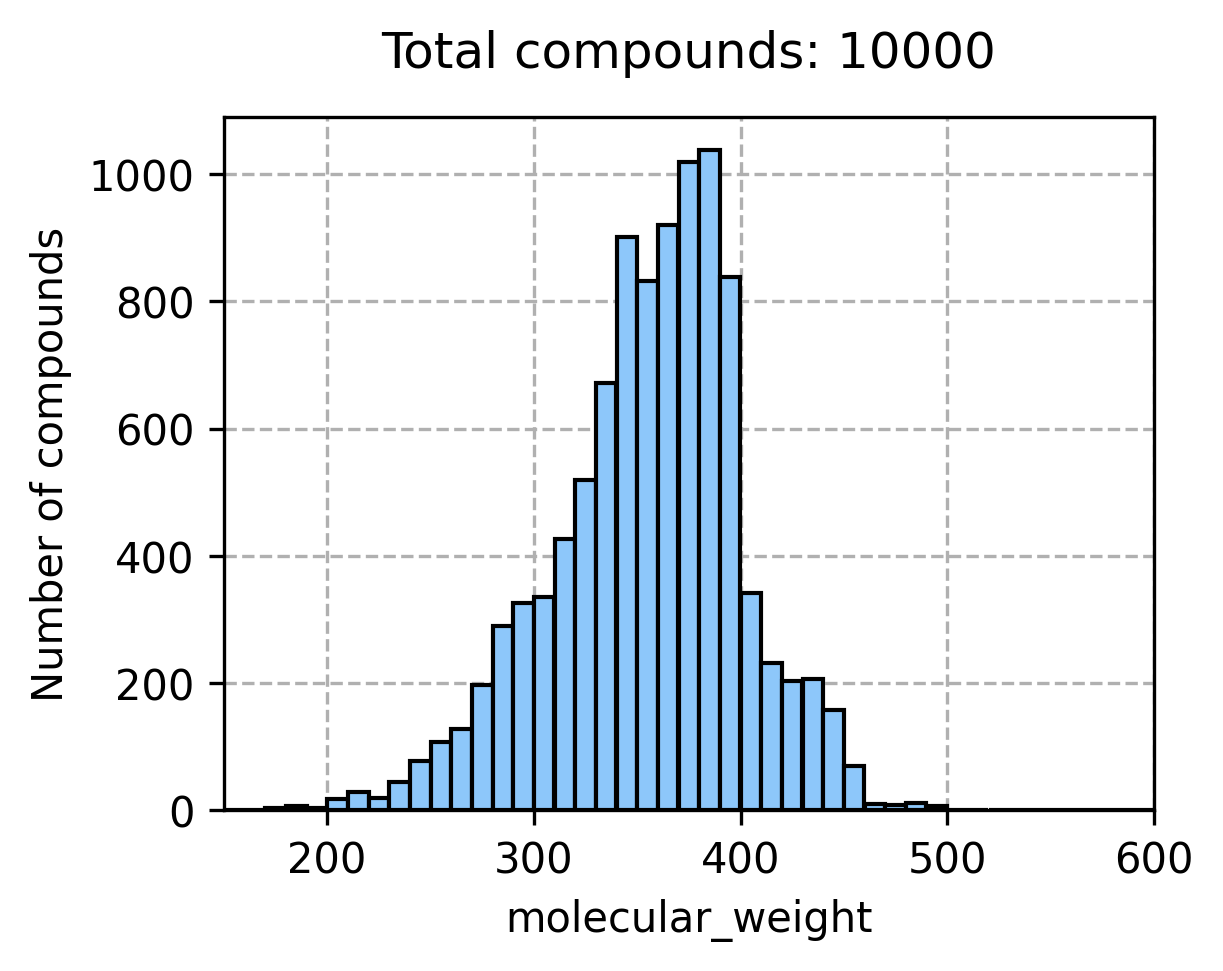

In [ ]:
lab = "molecular_weight"
data = eos7m30[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in range(0, 1000, 10)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
plt.xlim([150, 600])
plt.grid(linestyle='--', zorder=-2)
plt.show()

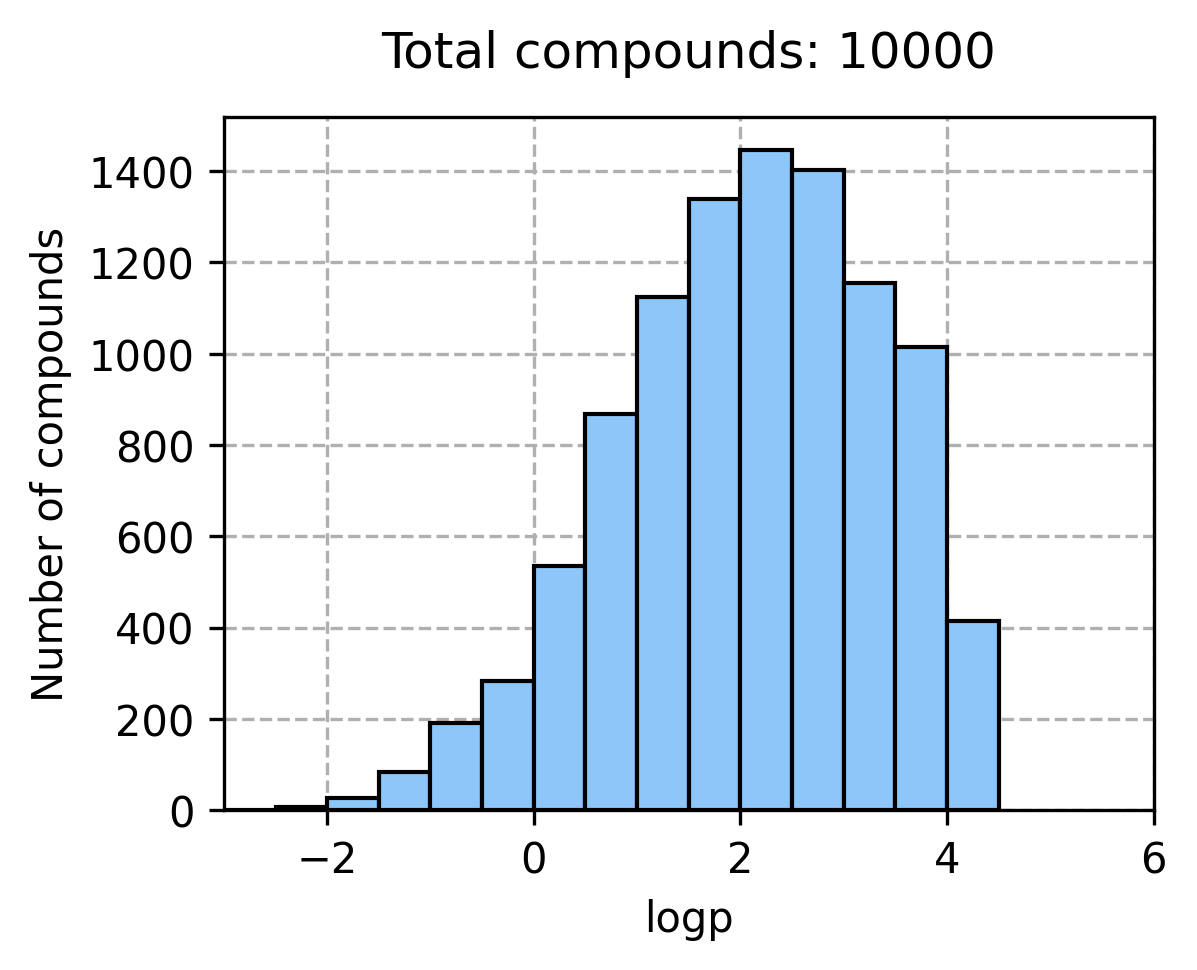

In [18]:
lab = "logp"
data = eos7m30[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in np.arange(-3, 5, 0.5)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
plt.xlim([-3, 6])
plt.grid(linestyle='--', zorder=-2)
plt.show()

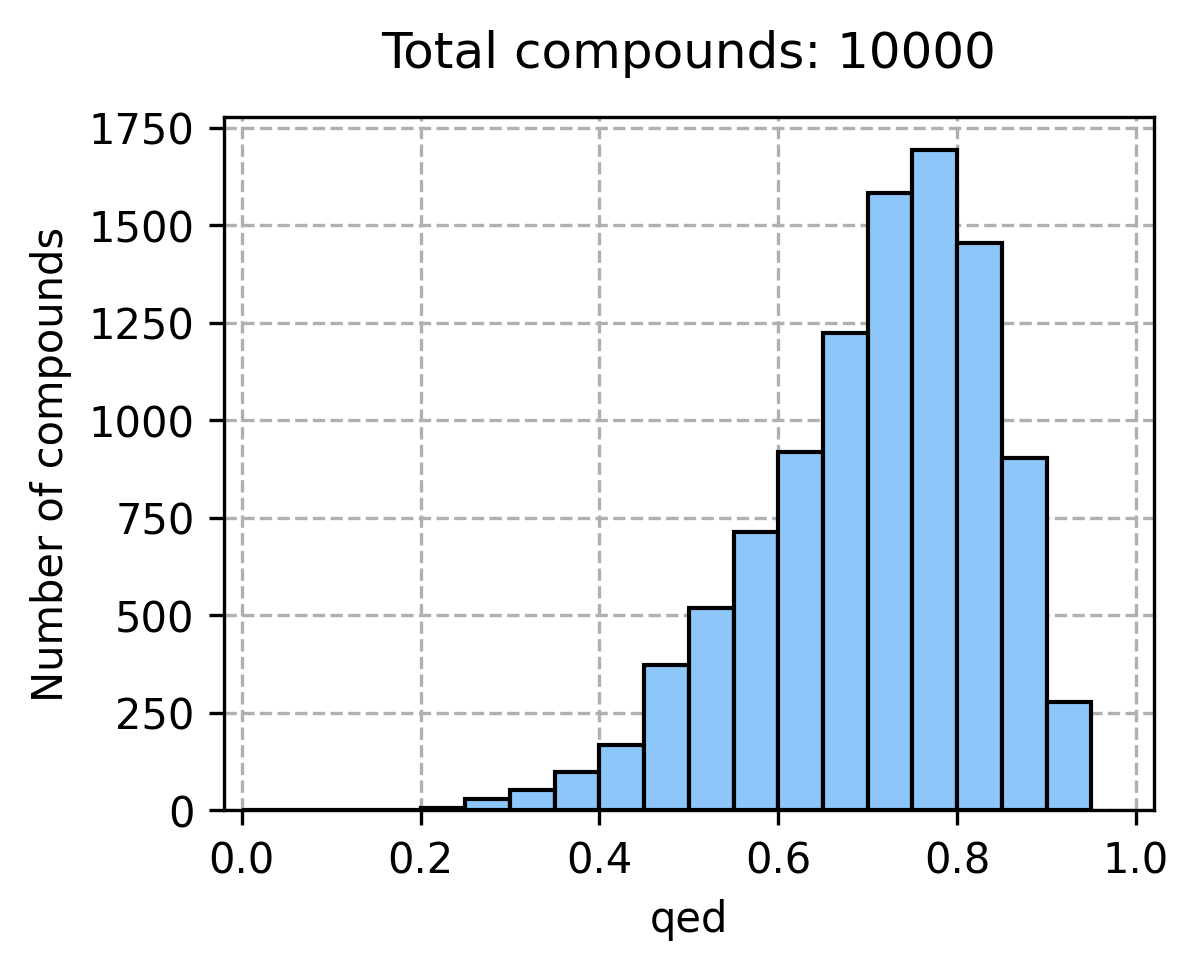

In [25]:
lab = "qed"
data = eos7m30[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in np.arange(0, 1, 0.05)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
plt.xlim([-0.02, 1.02])
plt.grid(linestyle='--', zorder=-2)
plt.show()

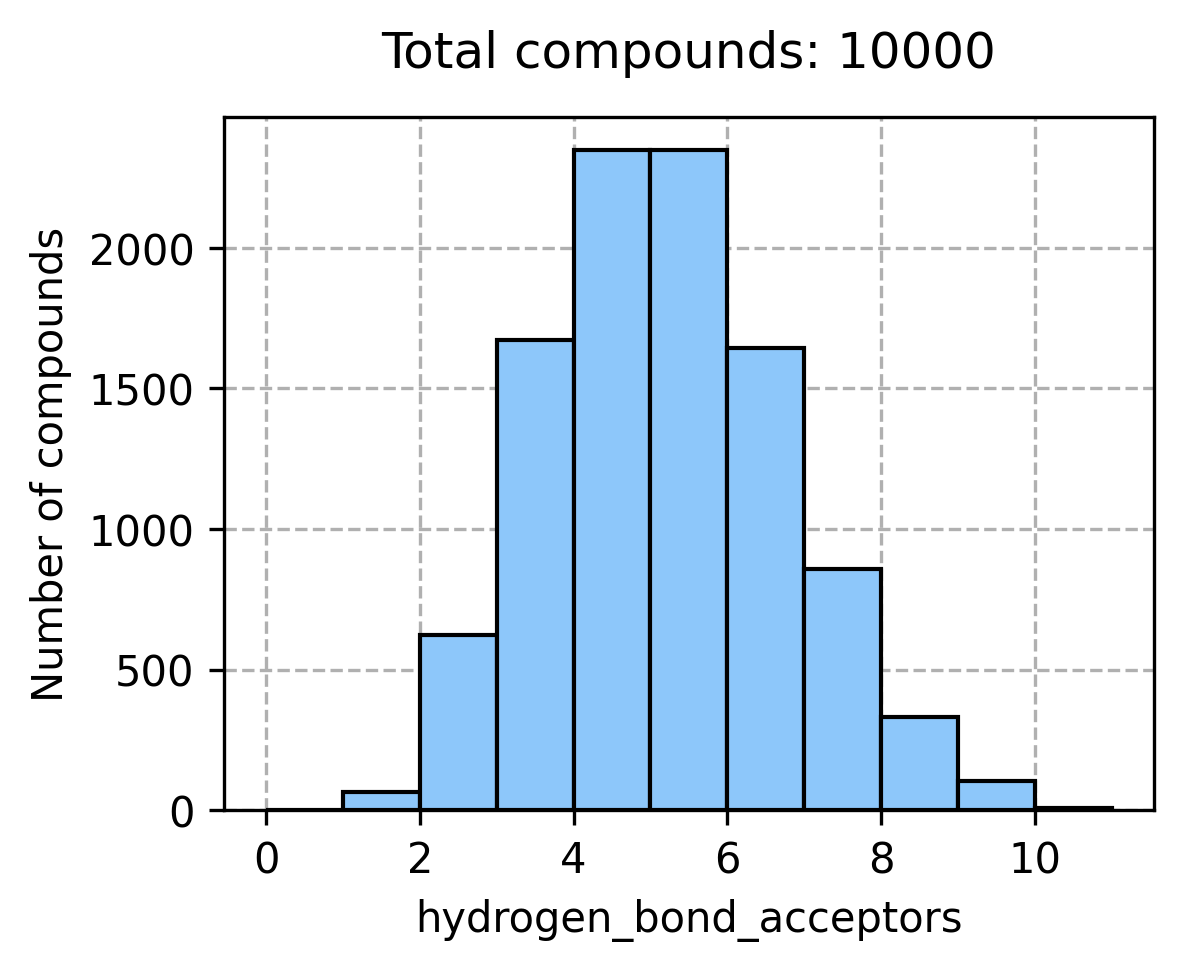

In [ ]:
lab = "hydrogen_bond_acceptors"
data = eos7m30[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in range(0, 12, 1)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
# plt.xlim([-0.02, 1.02])
plt.grid(linestyle='--', zorder=-2)
plt.show()

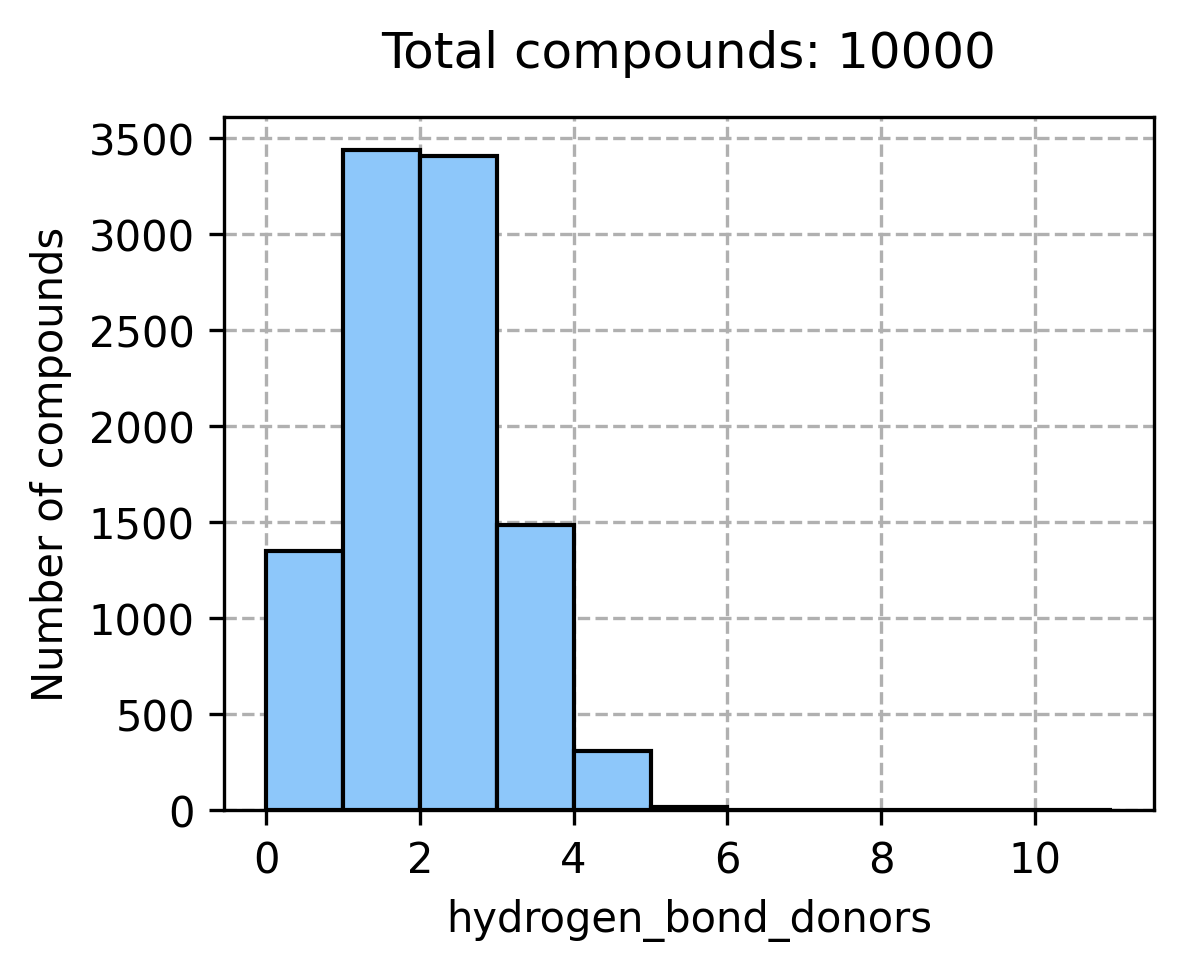

In [31]:
lab = "hydrogen_bond_donors"
data = eos7m30[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in range(0, 12, 1)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
# plt.xlim([-0.02, 1.02])
plt.grid(linestyle='--', zorder=-2)
plt.show()

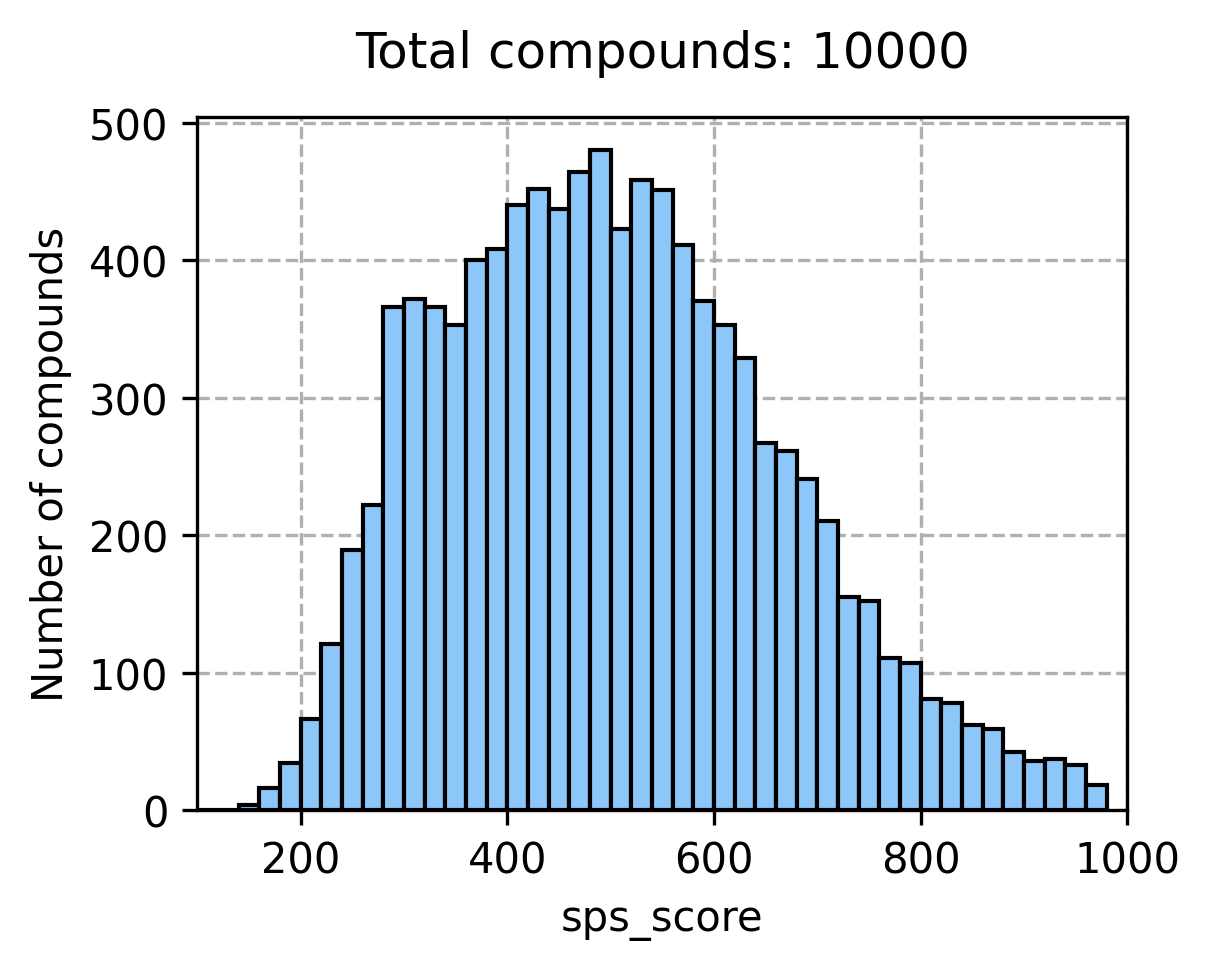

In [41]:
lab = "sps_score"
data = eos12x7[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in range(0, 1000, 20)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
plt.xlim([100, 1000])
plt.grid(linestyle='--', zorder=-2)
plt.show()

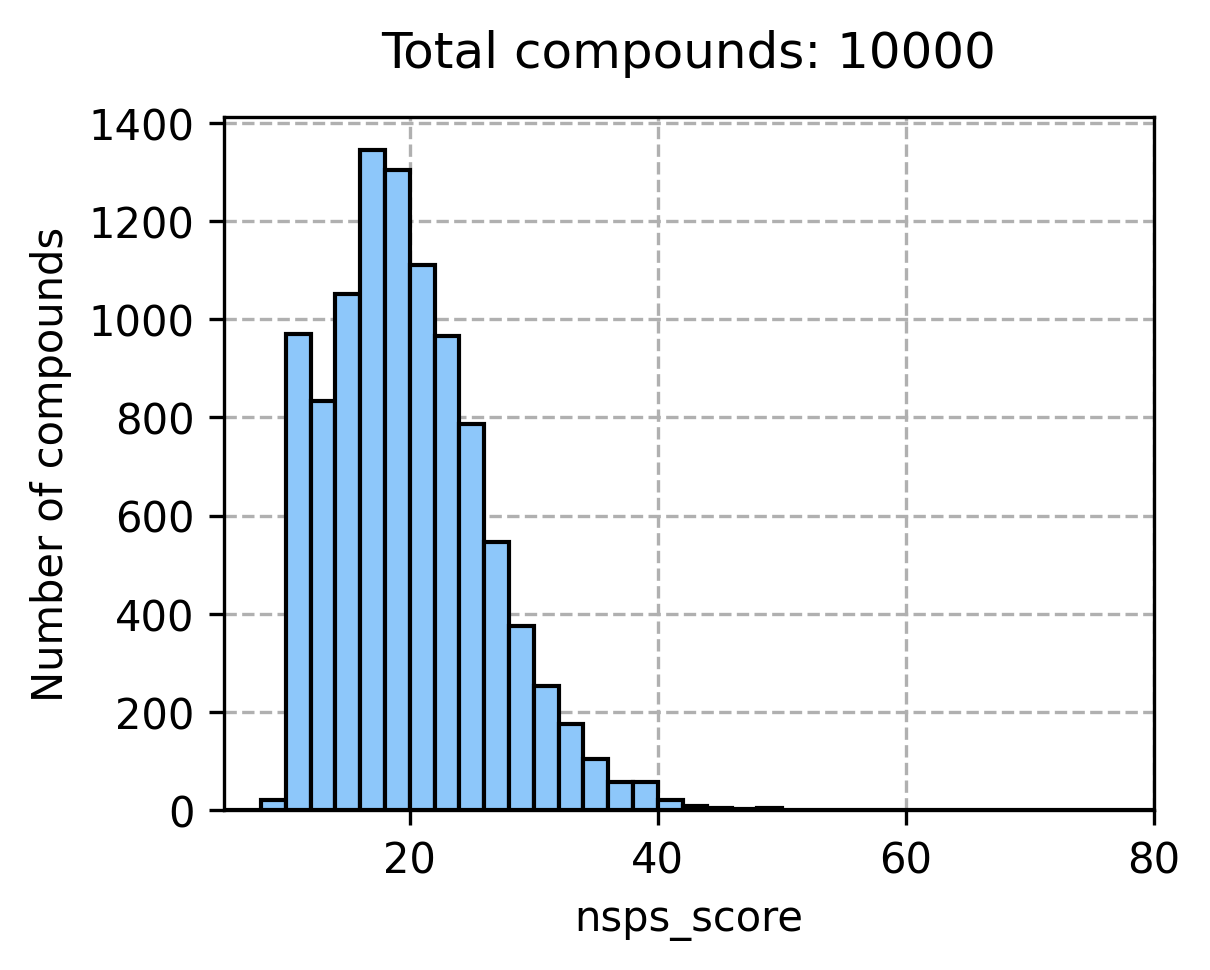

In [46]:
lab = "nsps_score"
data = eos12x7[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in range(0, 100, 2)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
plt.xlim([5, 80])
plt.grid(linestyle='--', zorder=-2)
plt.show()

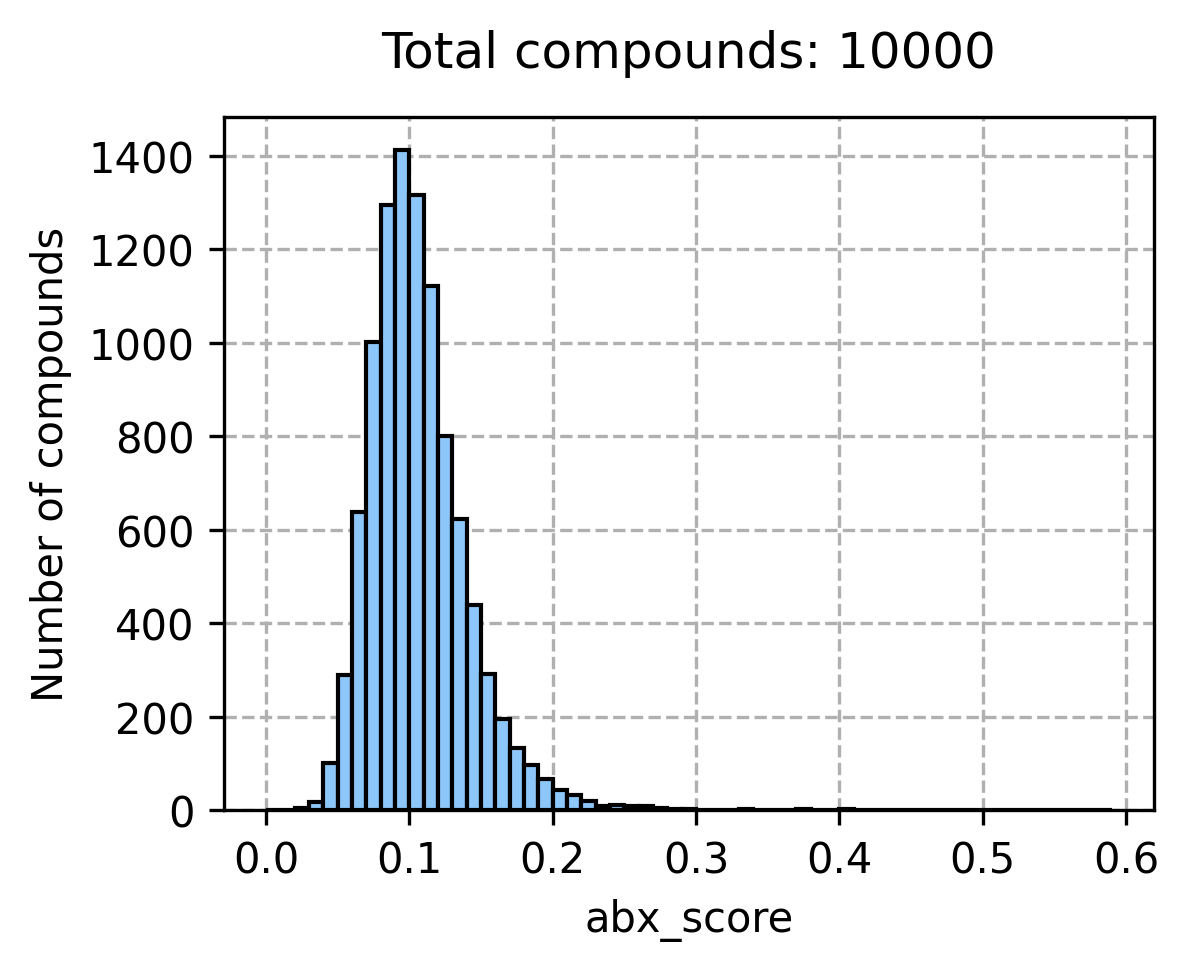

In [57]:
lab = "abx_score"
data = eos11sm[lab]
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(data, bins=[i for i in np.arange(0, 0.6, 0.01)], edgecolor='k', zorder=2, color='#8DC7FA')
plt.title(f"Total compounds: {len(data)}", pad=12)
plt.ylabel("Number of compounds")
plt.xlabel(lab)
# plt.xlim([5, 80])
plt.grid(linestyle='--', zorder=-2)
plt.show()